# Table of contents
1. package
2. data import
3. fit in DBSCAN, and set ipywidgets for simple dashboard
4. difference version of DBSCAN and fine tune

    4.1 DBSCAN, DBSCAN+SNN and HDBSCAN with optuna for opt

5. quality test

    5.1 without label, DBCV. 

    5.2 with label, ARI.
----

----
# 1. Load Package, and seed lock

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

locked_sampler = TPESampler(seed=67) # reason unknown so far, it's not working

----
# 2. Data Cleaning & Read data

In [2]:
def data_cleaning(x):
    temp = pd.read_csv(f"/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/{x}.txt",
                sep=r"\s+",
                header=None,)
    temp = temp.rename(columns={2:"cluster"})
    temp.to_csv(f"/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/{x}.csv")

data_cleaning("spiral")

In [33]:
def load_data(x):
    X = pd.read_csv(f"/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/{x}.csv",
                    index_col=0,  # truly have to be careful of this type of trivial bugs...
                    )
    X_d = X.drop(columns=['cluster'])
    y_true = X['cluster']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_d)

    return X_scaled, y_true
X_scaled, y_true = load_data("spiral")


---
# 3. fit in DBSCAN, and set ipywidgets for simple dashboard

In [31]:
@interact(
    eps=widgets.FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05, description='eps:'),
    min_samples=widgets.IntSlider(value=5, min=2, max=20, step=1, description='min_samples:')
)
def explore_dbscan(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    plt.figure(figsize=(24, 8))
    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')
    
    plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
    plt.legend()
    plt.show()
    

    print(f"Total dots: {len(X_scaled)}")
    print(f"core dots : {len(dbscan.core_sample_indices_)}")
    print(f"noise dots: {np.sum(is_noise)}")

interactive(children=(FloatSlider(value=0.3, description='eps:', max=1.0, min=0.05, step=0.05), IntSlider(valu…

----
# 4.1. DBSCAN, with Optuna

eps, min_samples

In [11]:
def objective(trial):
    eps = trial.suggest_float('eps', 0.01, 2.0)
    min_samples = trial.suggest_int('min_samples', 2, 20)
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize", sampler=locked_sampler)
study.optimize(objective, n_trials=50)

print("DBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

DBSCAN, with Optuna
Best paras:         {'eps': 0.49524301294670664, 'min_samples': 18}
Highest DBCV:       0.2029


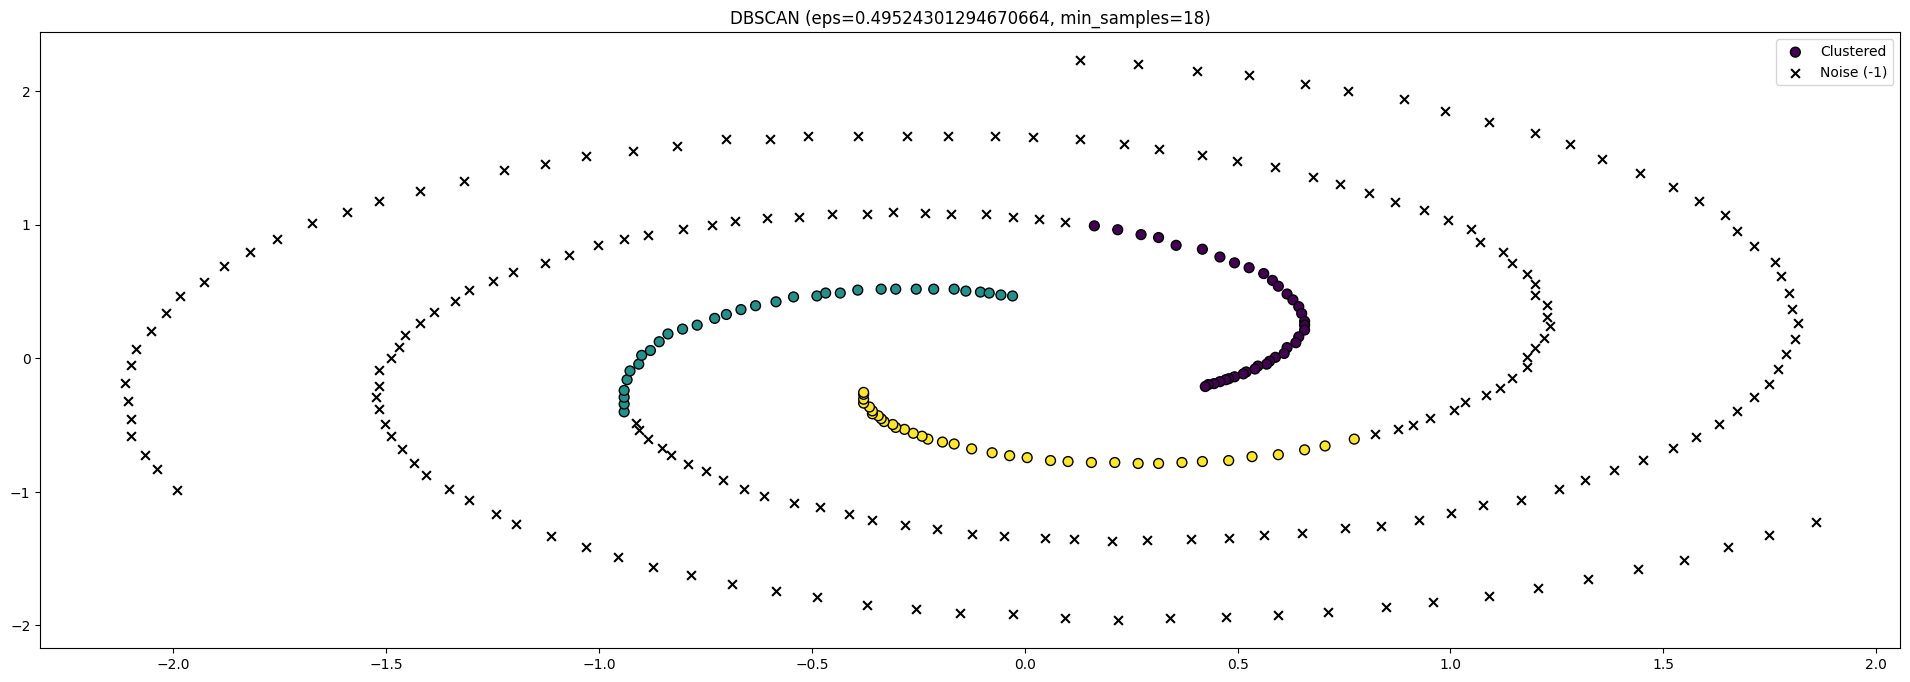

In [37]:
def labels_and_plot_dbscan(eps, min_samples, X_scaled):

    dbscan_snn = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan_snn.fit_predict(X_scaled)

    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(24, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples})")
    plt.legend()
    plt.show()

    return labels
dbscan_labels = labels_and_plot_dbscan(0.49524301294670664, 18, X_scaled)

----
# 4.2. DBSCAN + SNN, with Optuna

to deal with these 2 specific problems, we have to trade off to have 3 hyper-parameter

uneven density, high dimention

k, eps, min_samples

In [12]:
def objective(trial):
    k = trial.suggest_int('k', 10, 50)
    eps = trial.suggest_int('eps', 1, k - 1)
    min_samples = trial.suggest_int('min_samples', 3, 15)
    
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
    snn_distance = k - (graph @ graph.T).toarray()
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan.fit_predict(snn_distance)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("DBSCAN + SNN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")


DBSCAN + SNN, with Optuna
Best paras:         {'k': 21, 'eps': 7, 'min_samples': 8}
Highest DBCV:       0.2756


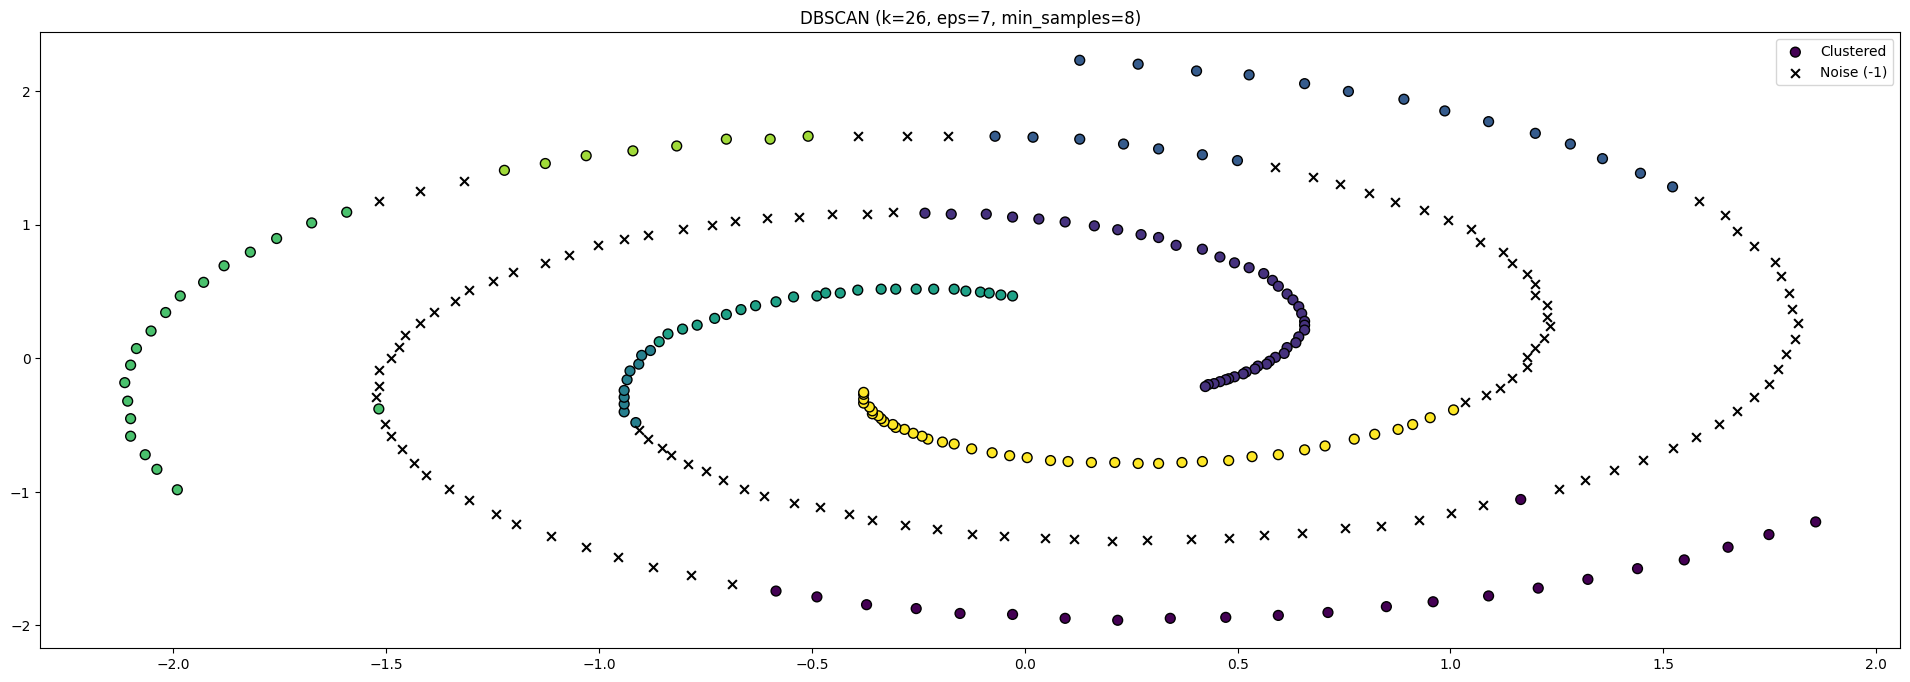

In [43]:
def labels_and_plot_dbscan_snn(k,eps,min_samples,X_scaled):
    k = 26
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')  # the connectivity here, will the amount of k neighbors, making a set of each member who contained or not eg. {0,1,0}

    snn_similarity = (graph @ graph.T).toarray() # the amount of common friends for each dot
    snn_distance = k - snn_similarity

    dbscan_snn = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan_snn.fit_predict(snn_distance)

    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(24, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"DBSCAN (k={k}, eps={eps}, min_samples={min_samples})")
    plt.legend()
    plt.show()

    return labels
dbscan_snn_labels = labels_and_plot_dbscan_snn(21, 7, 8, X_scaled)

----
# 4.3. HDBSCAN, with Optuna

pros, uneven density

corns, even but weird shape

min_cluster_size, min_samples

In [29]:
def objective(trial):
    min_cluster_size = trial.suggest_int('min_cluster_size', 3, 20)
    min_samples = trial.suggest_int('min_samples', 1, 20)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("HDBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

HDBSCAN, with Optuna
Best paras:         {'min_cluster_size': 13, 'min_samples': 16}
Highest DBCV:       0.1986


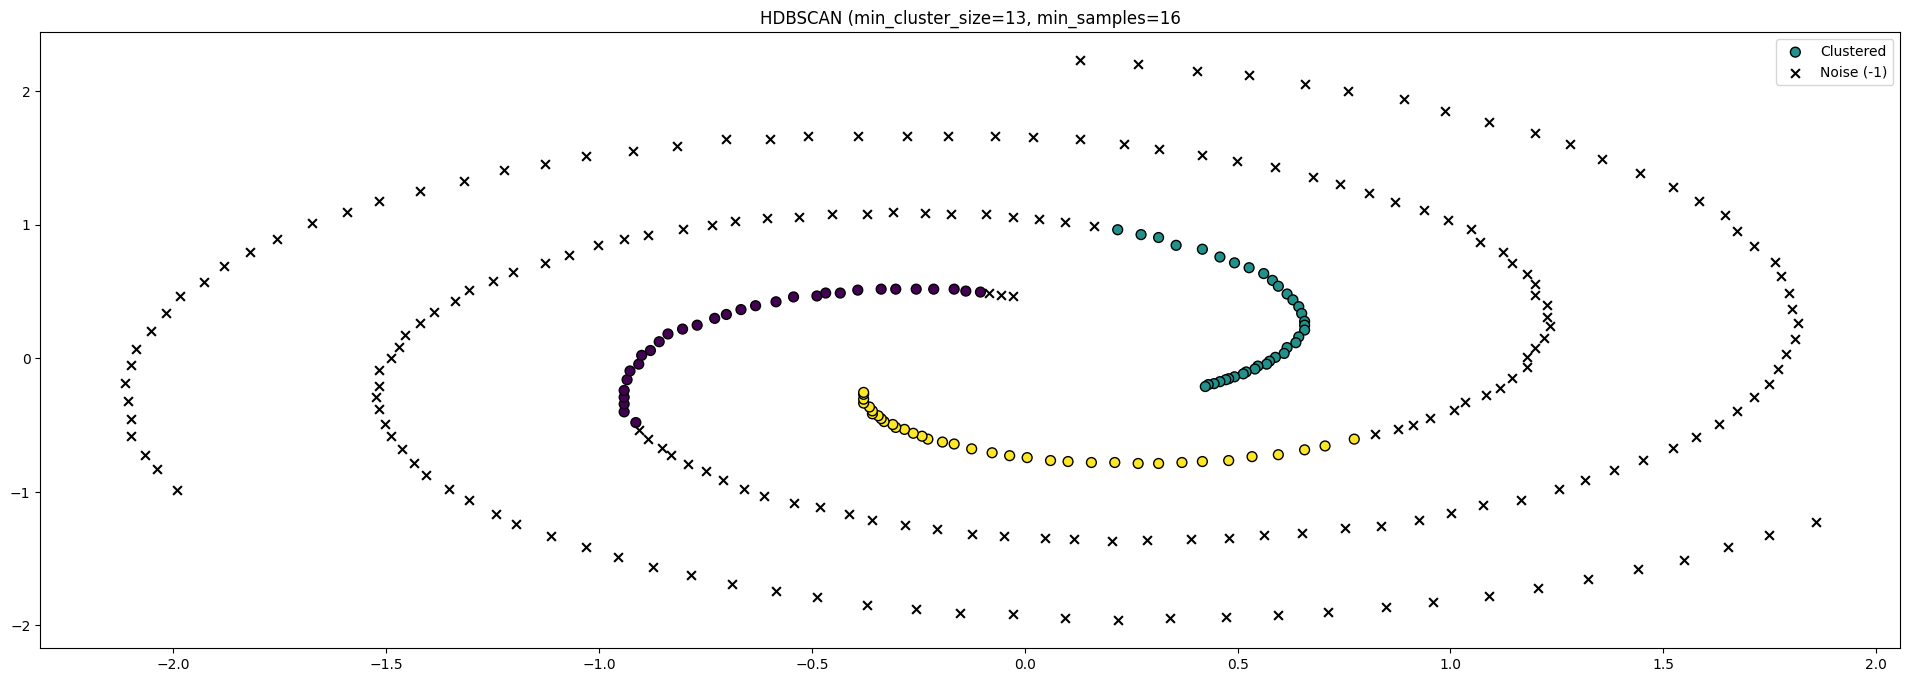

In [45]:
def labels_and_plot_hdbscan(min_cluster_size,min_samples,X_scaled):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)

    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(24, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"HDBSCAN (min_cluster_size={min_cluster_size}, min_samples={min_samples}")
    plt.legend()
    plt.show()

    return labels
hdbscan_labels = labels_and_plot_hdbscan(13, 16, X_scaled)

----
# 5. quality test

In [42]:
y_true.values
ari_score = adjusted_rand_score(y_true, dbscan_labels)
ari_score

0.10024159709796876

In [44]:
dbscan_snn_labels
ari_score = adjusted_rand_score(y_true, dbscan_snn_labels)
ari_score

0.1799710267806656

In [46]:
hdbscan_labels
ari_score = adjusted_rand_score(y_true, hdbscan_labels)
ari_score

0.09400694583015017